In [32]:
import pandas as pd
import sqlalchemy as db
from sqlalchemy import text, RowMapping, Sequence
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv('accommodation.csv')

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Text(0, 0.5, 'Стоимость')

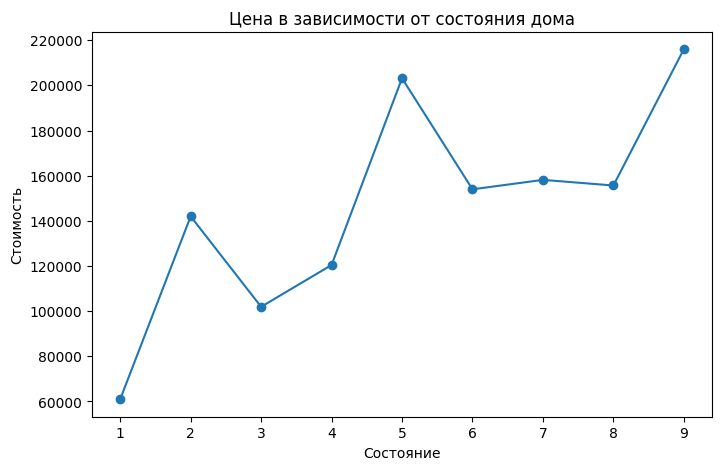

In [26]:
table = df[["OverallCond", "SalePrice"]].groupby("OverallCond").agg(["mean"])

plt.figure(figsize=(8, 5))

plt.plot(table, marker="o")

plt.title("Цена в зависимости от состояния дома")
plt.xlabel("Состояние")
plt.ylabel("Стоимость")


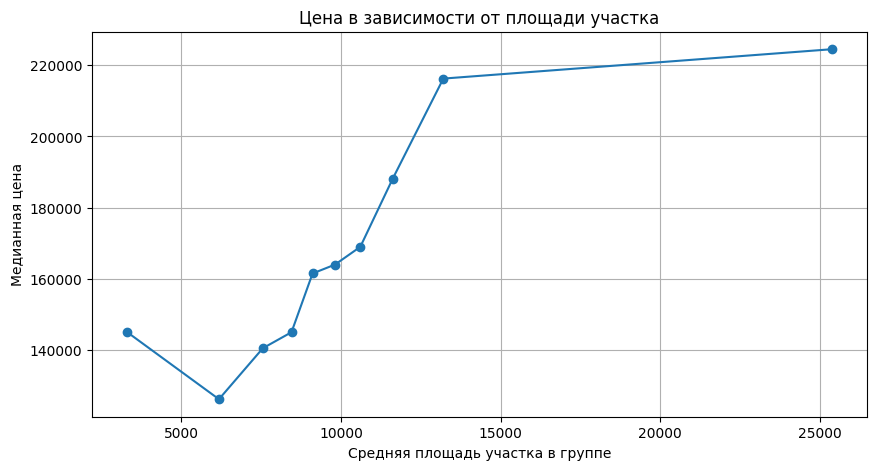

In [ ]:
df2 = df[["LotArea", "SalePrice"]].copy()

df2["LotAreaGroup"] = pd.qcut(
    df2["LotArea"],
    q=10,
    duplicates="drop"
)

table2 = (
    df2
    .groupby("LotAreaGroup", observed=True)
    .agg(
        avg_price=("SalePrice", "mean"),
        median_price=("SalePrice", "median"),
        avg_area=("LotArea", "mean"),
        count=("SalePrice", "count")
    )
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    table2["avg_area"],
    table2["median_price"],
    marker="o"
)

plt.title("Цена в зависимости от площади участка")
plt.xlabel("Средняя площадь участка в группе")
plt.ylabel("Медианная цена")
plt.grid(True)

plt.show()

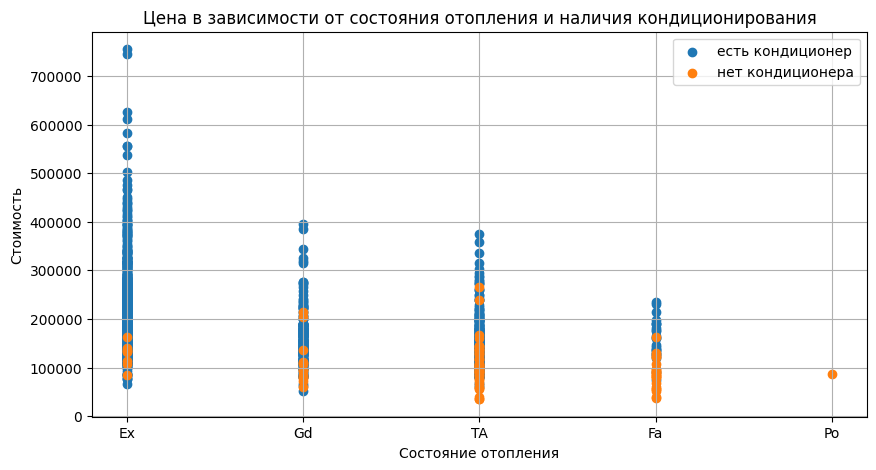

In [ ]:
dfY = df[df.CentralAir == 'Y']
dfN = df[df.CentralAir == 'N']

plt.figure(figsize=(10, 5))

plt.scatter(dfY['HeatingQC'], dfY['SalePrice'], marker="o")
plt.scatter(dfN['HeatingQC'], dfN['SalePrice'], marker="o")

plt.title("Цена в зависимости от состояния отопления и наличия кондиционирования")
plt.xlabel("Состояние отопления")
plt.ylabel("Стоимость")
plt.grid(True)
plt.legend(["есть кондиционер", "нет кондиционера"])

plt.show()

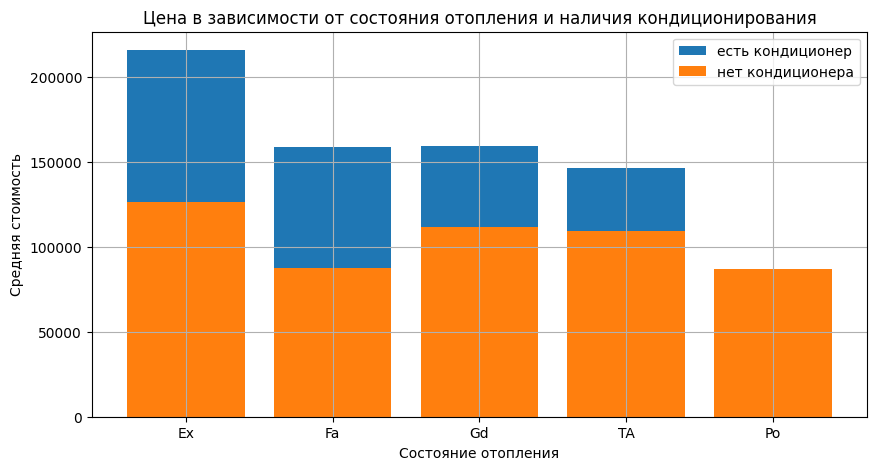

In [ ]:
dfY = df[df.CentralAir == 'Y'].groupby('HeatingQC').agg(
        avg_price=("SalePrice", "mean")).reset_index()

dfN = df[df.CentralAir == 'N'].groupby('HeatingQC').agg(
        avg_price=("SalePrice", "mean")).reset_index()

plt.figure(figsize=(10, 5))

plt.bar(dfY['HeatingQC'], dfY['avg_price'])
plt.bar(dfN['HeatingQC'], dfN['avg_price'])

plt.title("Цена в зависимости от состояния отопления и наличия кондиционирования")
plt.xlabel("Состояние отопления")
plt.ylabel("Средняя стоимость")
plt.grid(True)
plt.legend(["есть кондиционер", "нет кондиционера"])

plt.show()